### Hough Transform

In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [17]:
img = cv2.imread('data/yield.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Detect Circles in Image

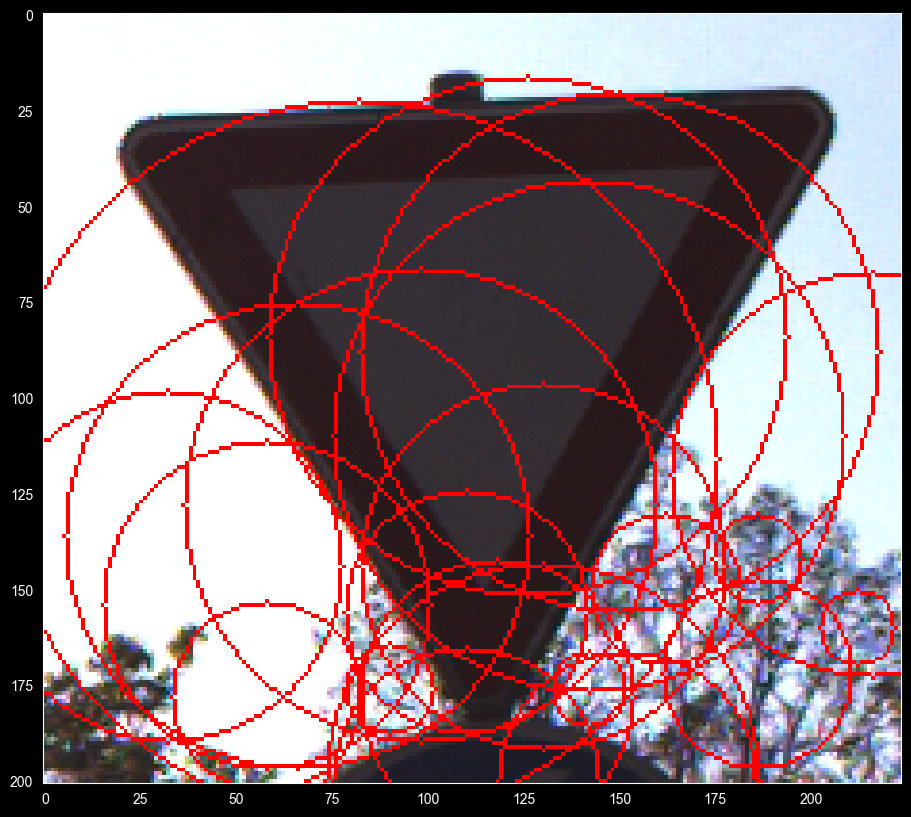

In [18]:
edges = cv2.Canny(gray, threshold1=100, threshold2=550)

circles = cv2.HoughCircles(edges,
                           cv2.HOUGH_GRADIENT,
                           dp=1, # The inverse ratio of the accumulator resolution to the image resolution. For example, if dp=1, the accumulator has the same resolution as the input image. If dp=2, the accumulator has half the width and height of the input image.
                           minDist=20, # Minimum distance between the centers of the detected circles. If the parameter is too small, multiple circles may be falsely detected in the same location. If it is too large, some circles may be missed.
                           param1=25, # The higher threshold for the Canny edge detector (the lower one is twice smaller). This parameter is used to detect edges in the image, which are then used to find circles. A higher value will result in fewer edges being detected, while a lower value will result in more edges being detected.
                           param2=25, # The accumulator threshold for the circle centers at the detection stage. The smaller it is, the more false circles may be detected. Circles, corresponding to the larger accumulator values, will be returned first.
                           minRadius=0, # Minimum circle radius. If the parameter is unknown, it is set to 0 by default and the algorithm will search for circles of any radius.
                           maxRadius=0) # Maximum circle radius. If the parameter is unknown, it is set to 0 by default and the algorithm will search for circles of any radius.
circles = np.uint16(np.around(circles))

copied_img = img.copy()

for i in circles[0, :]:
    cv2.circle(
        img=copied_img, center=i[0:2], radius=i[2], color=(255, 0, 0), thickness=1
    )

plt.imshow(copied_img)
plt.grid(False)

In [ ]:
def on_change(_):
    pass

controls_win = "Controls"
view_win = "View"

cv2.namedWindow(controls_win, cv2.WINDOW_NORMAL)
cv2.namedWindow(view_win, cv2.WINDOW_NORMAL)

# Trackbars live in the controls window
cv2.createTrackbar("canny_min_thres", controls_win, 100, 1000, on_change)
cv2.createTrackbar("canny_max_thres", controls_win, 550, 1000, on_change)

cv2.createTrackbar("dp", controls_win, 1, 4, on_change)
cv2.createTrackbar("minDist", controls_win, 20, 200, on_change)
cv2.createTrackbar("param1", controls_win, 25, 300, on_change)
cv2.createTrackbar("param2", controls_win, 25, 300, on_change)
cv2.createTrackbar("minRadius", controls_win, 0, 250, on_change)
cv2.createTrackbar("maxRadius", controls_win, 0, 250, on_change)


while True:
    if cv2.waitKey(1) == ord('q'):
        break

    canny_min_thres = cv2.getTrackbarPos("canny_min_thres", controls_win)
    canny_max_thres = cv2.getTrackbarPos("canny_max_thres", controls_win)

    dp = cv2.getTrackbarPos("dp", controls_win)
    minDist = cv2.getTrackbarPos("minDist", controls_win)
    param1 = cv2.getTrackbarPos("param1", controls_win)
    param2 = cv2.getTrackbarPos("param2", controls_win)
    minRadius = cv2.getTrackbarPos("minRadius", controls_win)
    maxRadius = cv2.getTrackbarPos("maxRadius", controls_win)

    cannyEdge = cv2.Canny(gray, canny_min_thres, canny_max_thres)

    # HoughCircles Detection
    circles = cv2.HoughCircles(cannyEdge,
                               cv2.HOUGH_GRADIENT,
                               dp=dp,
                               minDist=minDist,
                               param1=param1,
                               param2=param2,
                               minRadius=minRadius,
                               maxRadius=maxRadius)

    if circles is None or not circles.any():
        continue

    circles = np.uint16(np.around(circles))

    copied_img = img.copy()

    for i in circles[0, :]:
        cv2.circle(
            img=copied_img, center=i[0:2], radius=i[2], color=(255, 0, 0), thickness=1
        )

    cv2.imshow(view_win, copied_img)

cv2.destroyAllWindows()